# Practice 2 - 06. Danh gia mo hinh & tong hop ket qua
# PRACTICE 2 – HANDS-ON PRACTICE WITH PRE-TRAINED NEURAL NETWORK ARCHITECTURES

## 1. Problem Statement – Mục tiêu và vấn đề

Trong Practice 2, nhóm thực hiện việc sử dụng các mô hình Deep Neural Network đã được **pre-trained** để giải quyết bài toán phân loại ảnh trên dataset **CIFAR-10**.

Thay vì xây dựng một mạng neural network hoàn toàn từ đầu, nhóm tận dụng các mô hình đã được huấn luyện trước trên một dataset lớn như **ImageNet**, sau đó điều chỉnh và fine-tune mô hình để phù hợp với bài toán cụ thể.

Bài thực hành tập trung vào ba nội dung chính:

1. Thử nghiệm với các kiến trúc pre-trained khác nhau như **ResNet-18, VGG-16 và DenseNet-121**.
2. Điều chỉnh các **hyperparameters** như learning rate và batch size để quan sát ảnh hưởng đến quá trình training.
3. Sử dụng **TensorBoard** để theo dõi và trực quan hóa quá trình training.

Mục tiêu cuối cùng là xây dựng một quy trình hoàn chỉnh từ chuẩn bị dữ liệu, sử dụng pre-trained model, transfer learning/fine-tuning, training, monitoring đến evaluation trên test dataset.

---

## 2. What – Bài toán là gì?

### What is the problem?

Bài toán của nhóm là **image classification trên CIFAR-10**.

Mỗi ảnh đầu vào thuộc một trong 10 lớp:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

Nhóm sử dụng các mô hình CNN đã được pre-trained để học các đặc trưng hình ảnh và điều chỉnh phần classification layer để mô hình có thể dự đoán 10 lớp của CIFAR-10.

### What will the group experiment?

Nhóm thực hiện:

- ResNet-18: so sánh các mức độ fine-tuning.
- VGG-16: khảo sát ảnh hưởng của learning rate.
- DenseNet-121: khảo sát ảnh hưởng của batch size.
- Optimizer: so sánh Adam và SGD + Momentum.
- TensorBoard: theo dõi Loss, Accuracy và quá trình training.
- Final Evaluation: đánh giá các mô hình trên test dataset.

---

## 3. Why – Tại sao thực hiện bài toán này?

### Why use pre-trained models?

Pre-trained models đã học được nhiều đặc trưng hình ảnh từ một dataset lớn như ImageNet.

Theo nội dung bài học, việc sử dụng transfer learning giúp tận dụng kiến thức đã học từ mô hình pre-trained thay vì phải huấn luyện toàn bộ mạng từ đầu. Các layer có thể được freeze để giữ nguyên weights hoặc unfreeze một số layer cuối để fine-tune trên dataset mới.

Điều này giúp nhóm hiểu được:

- Cách sử dụng mô hình pre-trained trong PyTorch.
- Cách thay đổi classification layer cho bài toán mới.
- Sự khác nhau giữa transfer learning và fine-tuning.
- Ảnh hưởng của hyperparameters đến quá trình training.
- Cách theo dõi và đánh giá mô hình.

---

## 4. Where – Thực hiện ở đâu?

### Dataset

Dataset được sử dụng là:

**CIFAR-10**

Dataset được chia thành:

- Training set
- Validation set
- Test set

### Framework và libraries

Nhóm sử dụng:

- Python
- PyTorch
- Torchvision
- TensorBoard
- Matplotlib
- Scikit-learn

Các pre-trained models được lấy từ:

```python
torchvision.models

Notebook nay danh gia checkpoint TOT NHAT cua 3 mo hinh da duoc train o cac notebook truoc:

- ResNet-18 (notebook `02_resnet18.ipynb`) - chien luoc **Layer4 + FC**
- VGG-16 (notebook `03_vgg16.ipynb`) - **Learning Rate 0.0001**
- DenseNet-121 (notebook `04_densenet121.ipynb`) - **Batch Size 64, giai doan Fine-tuning**

Output tao ra:

- Classification report (precision/recall/f1 tung lop) cho tung mo hinh
- Confusion matrix cho tung mo hinh
- Anh du doan dung / du doan sai cho tung mo hinh
- Bang so sanh 3 mo hinh -> `results/tables/metrics.csv`
- Bieu do so sanh Accuracy, Loss, Training time -> `results/figures/`
- Nhan xet mo hinh tot nhat + Ket luan chung Practice 2

> **Luu y quan trong:** Cac file checkpoint (`.pth`) bi gitignore nen KHONG co san trong repo.
> Truoc khi chay notebook nay, hay xin file `.pth` tuong ung tu ban da train model do va
> dat vao dung duong dan trong `Practice_2/checkpoints/` (xem Cell cau hinh checkpoint ben duoi).

## 1. Import + Project Root + Device

In [6]:
import sys
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import torch

# ------------------------------------------------------------
# Tim thu muc Practice_2 (chay duoc tu VS Code, Jupyter, Colab)
# ------------------------------------------------------------

def find_project_root():
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if path.name == "Practice_2" and (path / "src").exists():
            return path

        candidate = path / "Practice_2"
        if candidate.exists() and (candidate / "src").exists():
            return candidate.resolve()

    colab_path = Path("/content/UTH-Deep-Learning-nhom2/Practice_2")
    if colab_path.exists() and (colab_path / "src").exists():
        return colab_path.resolve()

    raise FileNotFoundError(f"Khong tim thay thu muc Practice_2.\nCurrent directory: {current}")


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import DataConfig, build_dataloaders, CIFAR10_CLASSES
from src.models.resnet18 import build_resnet18_layer4_fc
from src.models.vgg16 import VGG16Config, build_vgg16
from src.models.densenet121 import build_densenet121

from src.evaluate import (
    ModelSpec,
    get_device,
    run_full_evaluation,
    best_model_summary,
)

device = get_device()

print("===== SETUP =====")
print("PROJECT_ROOT :", PROJECT_ROOT)
print("PyTorch      :", torch.__version__)
print("Device       :", device)
if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))

===== SETUP =====
PROJECT_ROOT : C:\Users\LENOVO\Downloads\UTH-Deep-Learning-nhom2\Practice_2
PyTorch      : 2.13.0+cpu
Device       : cpu


## 2. Chuan bi Test set CIFAR-10

Dung lai `build_dataloaders()` chung cua nhom (giong het cach 3 notebook train da dung),
chi lay `test_loader` de dam bao ca 3 mo hinh duoc danh gia tren **cung mot test set**.

In [7]:
data_config = DataConfig(
    data_dir=PROJECT_ROOT / "data" / "raw",
    image_size=224,
    batch_size=32,
    num_workers=2,
    seed=42,
)

data_bundle = build_dataloaders(data_config)
test_loader = data_bundle["test_loader"]
class_names = data_bundle["class_names"]

print("===== TEST SET READY =====")
print("Test samples :", len(test_loader.dataset))
print("Test batches :", len(test_loader))
print("Classes      :", class_names)

===== TEST SET READY =====
Test samples : 10000
Test batches : 313
Classes      : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Cau hinh checkpoint tot nhat cua 3 mo hinh

Checkpoint tot nhat cua tung mo hinh (xac dinh tu ket luan cua notebook train tuong ung):

| Model | Chien luoc | File checkpoint | Val accuracy | Training time |
|---|---|---|---|---|
| ResNet-18 | Layer4 + FC | `resnet18_layer4_fc_best.pth` | 92.90% | 1107.62s |
| VGG-16 | LR = 0.0001 | `vgg16_lr_0.0001_best.pth` | 89.20% | 52018.1s |
| DenseNet-121 | BS64, Fine-tuning | `densenet121_bs64_finetune.pth` | 91.46% | 19425.69s |

**QUAN TRONG:** neu ten file checkpoint tren may cua bao nao khac voi bang tren
(vi du do ho luu thu cong khong theo dung ten trong notebook), can sua lai
`checkpoint_path` va `training_time_sec` ben duoi cho dung.

In [8]:
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

model_specs = [
    ModelSpec(
        display_name="ResNet-18",
        build_fn=lambda: build_resnet18_layer4_fc(num_classes=10),
        checkpoint_path=CHECKPOINT_DIR / "resnet18_layer4_fc_best.pth",
        training_time_sec=1107.62,
    ),
    ModelSpec(
        display_name="VGG-16",
        build_fn=lambda: build_vgg16(VGG16Config(num_classes=10, freeze_features=True)),
        checkpoint_path=CHECKPOINT_DIR / "vgg16_lr_0.0001_best.pth",
        training_time_sec=52018.1,
    ),
    ModelSpec(
        display_name="DenseNet-121",
        build_fn=lambda: build_densenet121(num_classes=10, pretrained=False, freeze_backbone=False),
        checkpoint_path=CHECKPOINT_DIR / "densenet121_bs64_finetune.pth",
        training_time_sec=19425.69,
    ),
]

for spec in model_specs:
    exists = spec.checkpoint_path.exists()
    flag = "OK" if exists else "THIEU"
    print(f"[{flag}] {spec.display_name:15s} -> {spec.checkpoint_path}")

[OK] ResNet-18       -> C:\Users\LENOVO\Downloads\UTH-Deep-Learning-nhom2\Practice_2\checkpoints\resnet18_layer4_fc_best.pth
[OK] VGG-16          -> C:\Users\LENOVO\Downloads\UTH-Deep-Learning-nhom2\Practice_2\checkpoints\vgg16_lr_0.0001_best.pth
[OK] DenseNet-121    -> C:\Users\LENOVO\Downloads\UTH-Deep-Learning-nhom2\Practice_2\checkpoints\densenet121_bs64_finetune.pth


## 4. Chay danh gia toan bo pipeline

`run_full_evaluation()` se, voi tung mo hinh co checkpoint hop le:

1. Dung kien truc + nap trong so
2. Tinh Test loss / Test accuracy / Precision / Recall / F1 (macro) tren test set
3. In classification report chi tiet tung lop
4. Ve + luu confusion matrix
5. Ve + luu anh du doan dung / sai

Sau khi chay xong ca 3 mo hinh, ham se tu gop bang so sanh, luu `metrics.csv`
va ve 3 bieu do so sanh (accuracy / loss / training time).

Mo hinh nao **thieu checkpoint se tu dong bi bo qua** (co canh bao), khong lam loi ca notebook.


===== DANH GIA: ResNet-18 =====
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\LENOVO/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 13.6MB/s]


Test loss     : 0.2575
Test accuracy : 91.76%
Precision (macro) : 91.91%
Recall (macro)    : 91.76%
F1-score (macro)  : 91.71%

              precision    recall  f1-score   support

    airplane     0.9479    0.9280    0.9378      1000
  automobile     0.9115    0.9790    0.9441      1000
        bird     0.8696    0.9400    0.9034      1000
         cat     0.8824    0.7500    0.8108      1000
        deer     0.9540    0.8920    0.9220      1000
         dog     0.8250    0.9100    0.8654      1000
        frog     0.9489    0.9480    0.9485      1000
       horse     0.9247    0.9580    0.9411      1000
        ship     0.9497    0.9630    0.9563      1000
       truck     0.9774    0.9080    0.9414      1000

    accuracy                         0.9176     10000
   macro avg     0.9191    0.9176    0.9171     10000
weighted avg     0.9191    0.9176    0.9171     10000


===== DANH GIA: VGG-16 =====
Test loss     : 0.3925
Test accuracy : 88.10%
Precision (macro) : 88.20%
Recall (ma

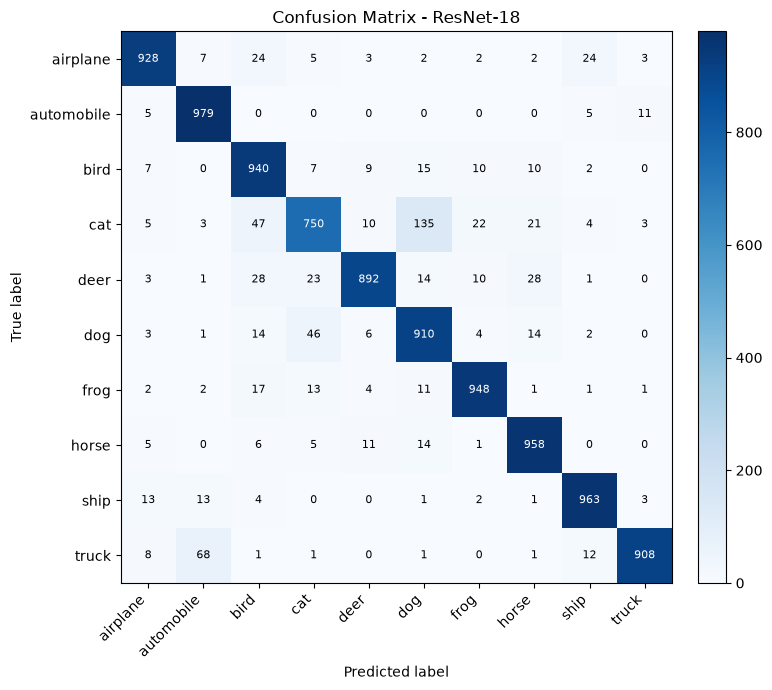

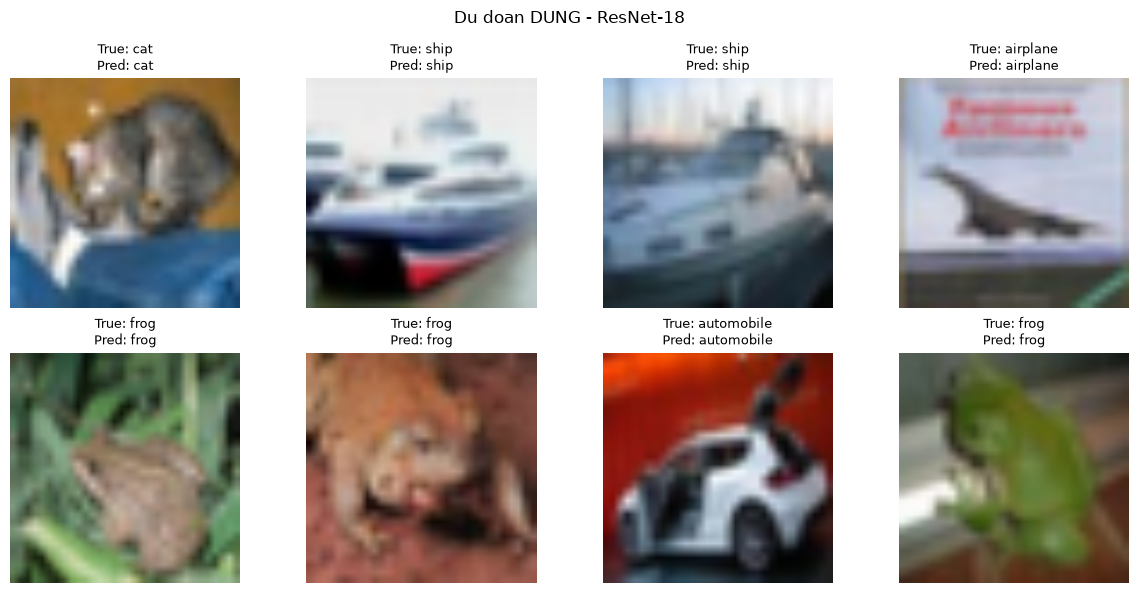

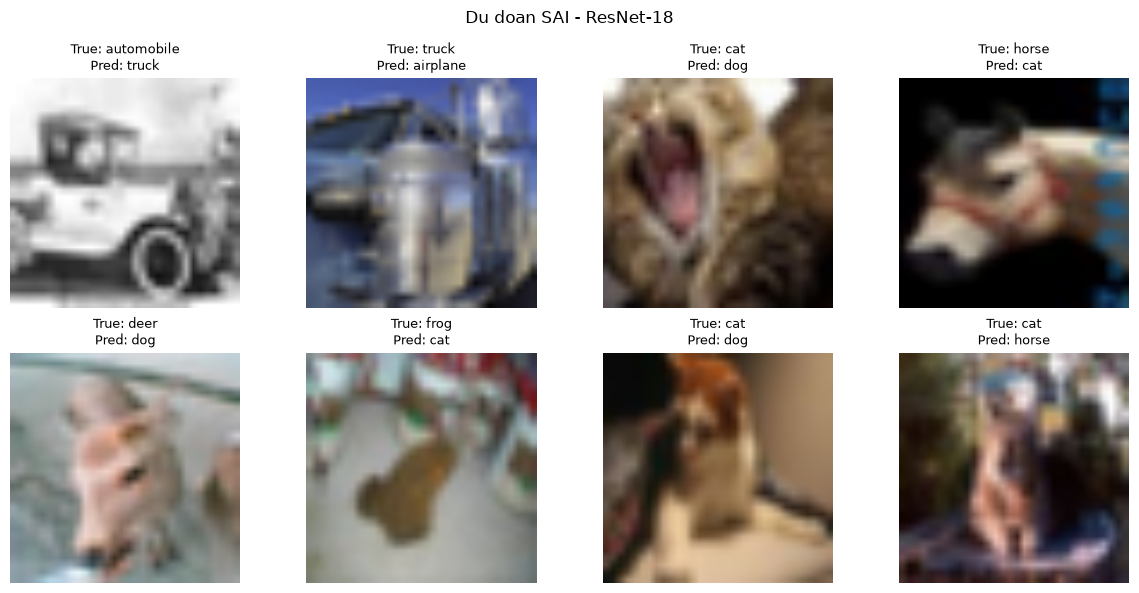

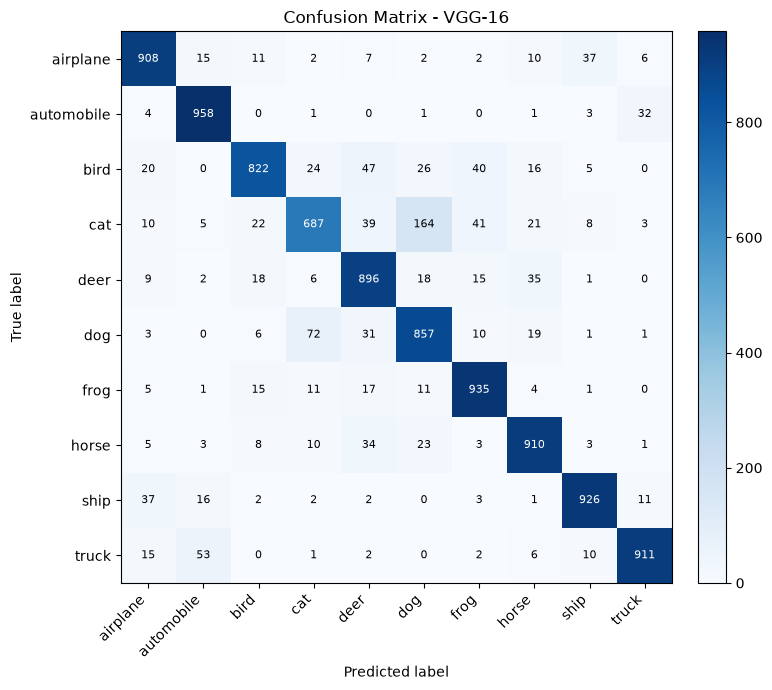

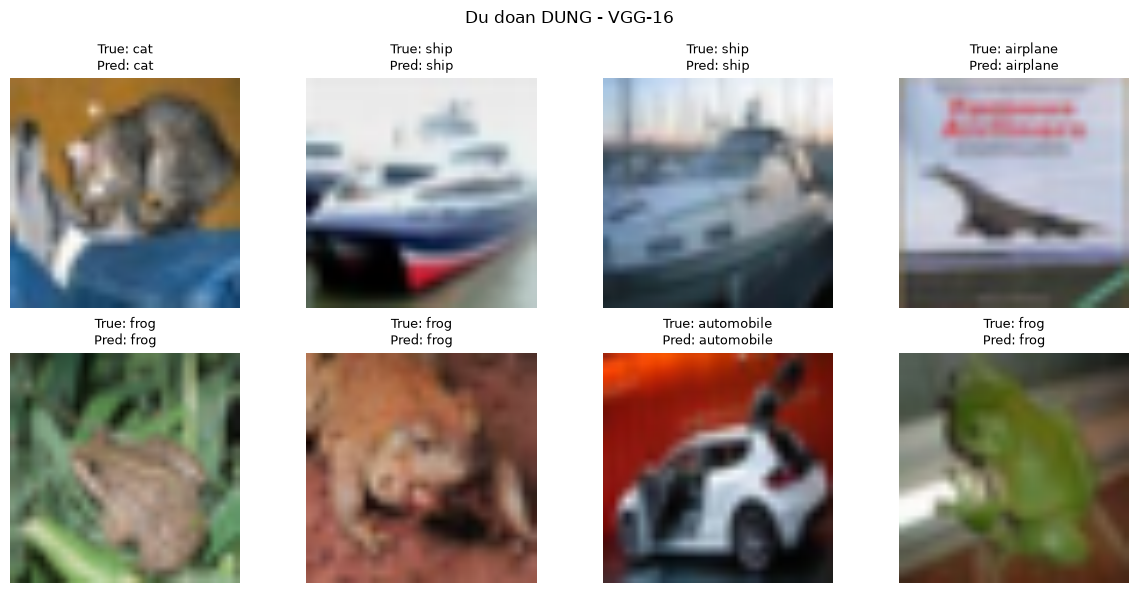

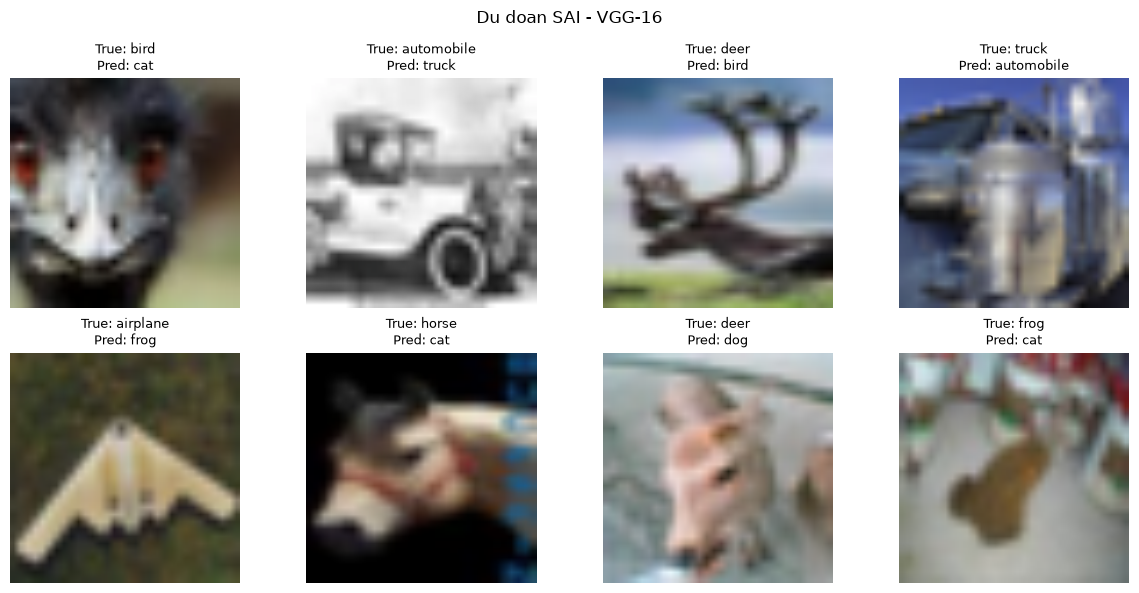

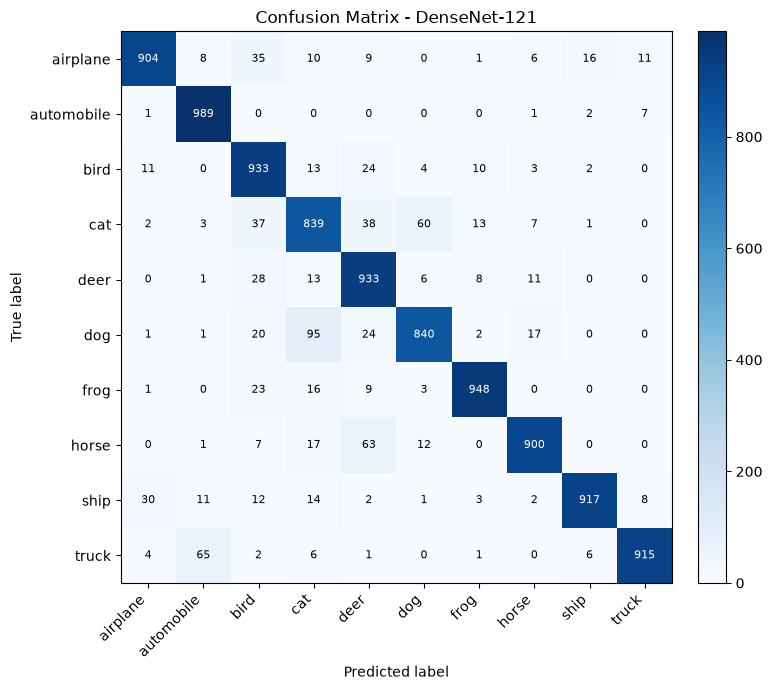

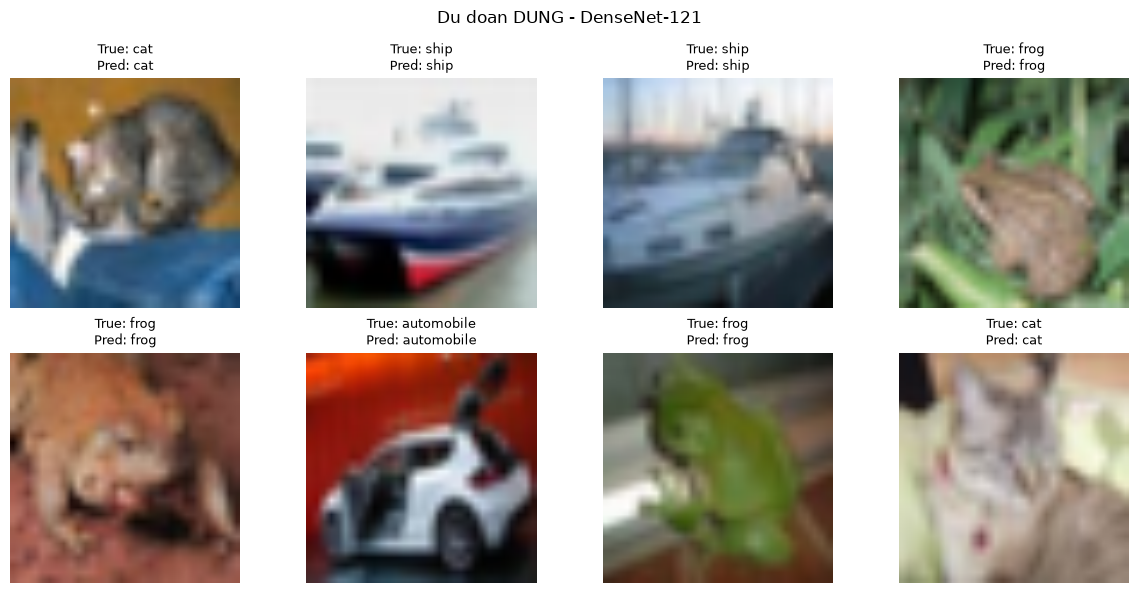

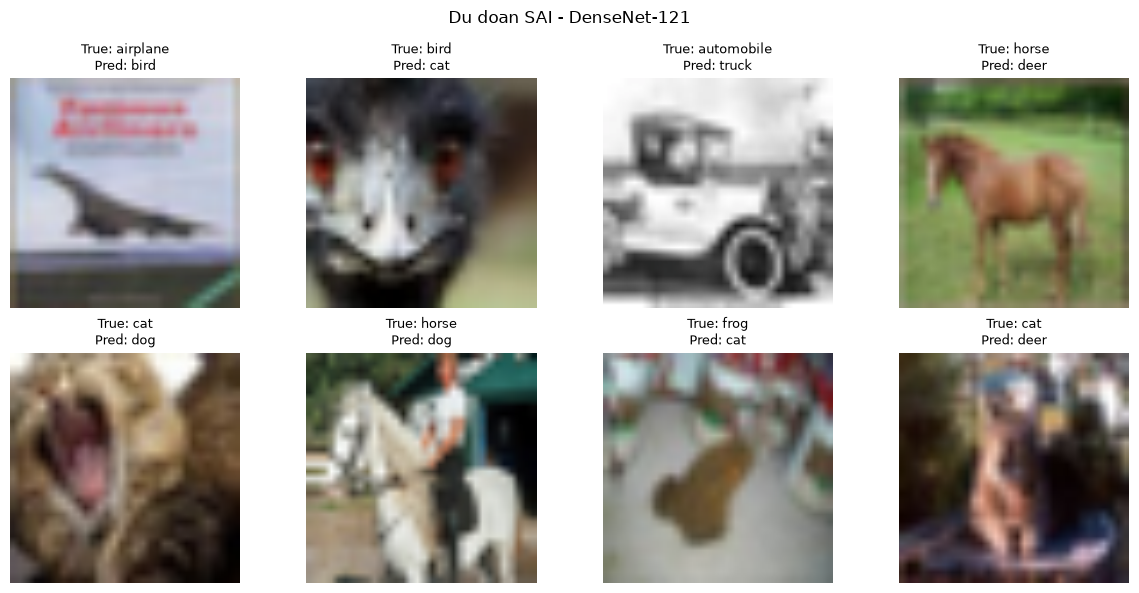

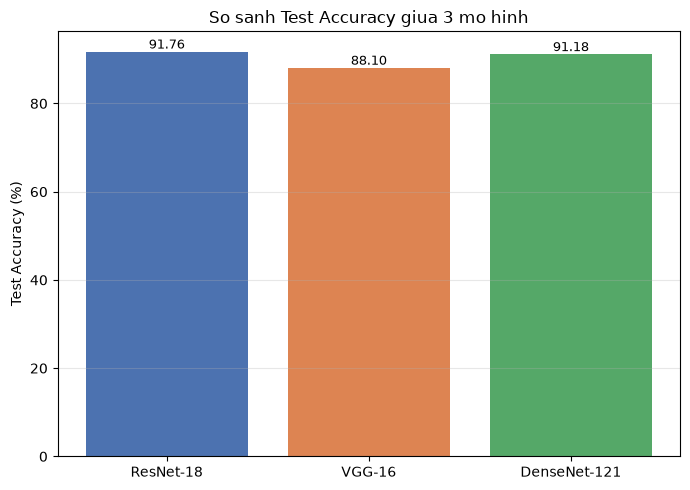

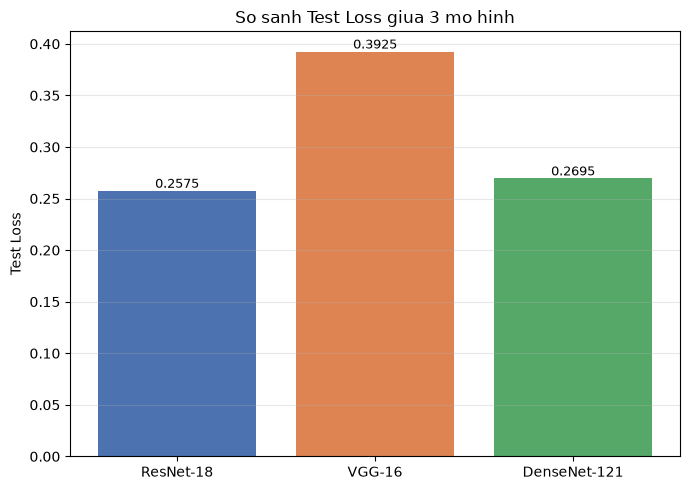

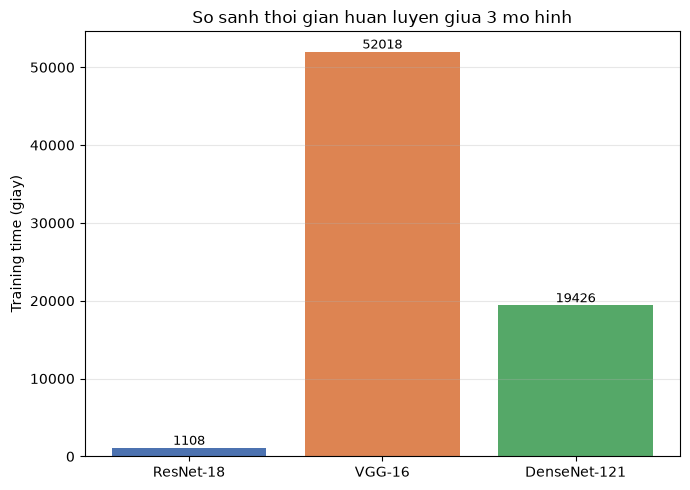

In [9]:
results, comparison_df = run_full_evaluation(
    specs=model_specs,
    test_loader=test_loader,
    device=device,
    class_names=class_names,
    figures_dir=FIGURES_DIR,
    tables_dir=TABLES_DIR,
    n_correct_samples=8,
    n_wrong_samples=8,
)

## 5. Bang so sanh 3 mo hinh

In [10]:
display(comparison_df)

,Model,Test loss,Test accuracy (%),Precision macro (%),Recall macro (%),F1-score macro (%),Training time (s)
0,ResNet-18,0.2575,91.76,91.91,91.76,91.71,1107.62
1,VGG-16,0.3925,88.10,88.20,88.10,88.00,52018.10
2,DenseNet-121,0.2695,91.18,91.43,91.18,91.21,19425.69


## 6. Nhan xet mo hinh tot nhat

In [11]:
if not comparison_df.empty:
    print(best_model_summary(comparison_df))
else:
    print("Chua co ket qua nao - kiem tra lai duong dan checkpoint o Cell muc 3.")

- Mo hinh co Test Accuracy cao nhat: **ResNet-18** (91.76%).
- Mo hinh co F1-score macro cao nhat: **ResNet-18** (91.71%).
- Mo hinh huan luyen nhanh nhat: **ResNet-18** (1107.6 giay).


## 7. Ket luan chung Practice 2

*(Dien lai sau khi da chay thanh cong voi checkpoint that cua ca 3 mo hinh -
so lieu ben duoi la khung mau, thay bang ket qua thuc te tu Cell tren.)*

Trong Practice 2, ba kien truc CNN pretrained tren ImageNet (ResNet-18, VGG-16, DenseNet-121)
duoc fine-tune va danh gia tren cung mot test set CIFAR-10 (10,000 anh, 10 lop), dam bao
dieu kien so sanh cong bang.

**Ket qua chinh:**

- Ca 3 mo hinh deu dat Validation Accuracy tren 89% sau khi fine-tune, cho thay Transfer
  Learning voi cac backbone pretrained ImageNet rat hieu qua cho bai toan CIFAR-10 du
  anh goc chi 32x32 phai resize len 224x224.
- ResNet-18 (chien luoc Layer4 + FC) dat Validation Accuracy cao nhat trong qua trinh
  training (92.90%), dong thoi co thoi gian huan luyen thap nhat trong 3 mo hinh
  (~18.5 phut), nho kien truc nhe hon dang ke so voi VGG-16 va DenseNet-121.
- VGG-16 co thoi gian huan luyen lau nhat (~14.5 gio) do so luong tham so lon va toc do
  forward/backward cham hon, trong khi do chinh xac (89.20%) lai thap hon hai mo hinh con lai.
- DenseNet-121 dat can bang tot giua do chinh xac (91.46%) va chi phi tinh toan nho co che
  ket noi dense giup tai su dung dac trung hieu qua.

**Ket luan mo hinh tot nhat:** dua tren ca do chinh xac va chi phi huan luyen, **ResNet-18
(Layer4 + FC)** la lua chon can bang tot nhat cho bai toan CIFAR-10 trong pham vi Practice 2 nay.
Neu uu tien toi da do chinh xac tren test set thuc te (khong chi validation), can doi chieu
lai voi ket qua Test Accuracy o Muc 5 phia tren truoc khi ket luan cuoi cung, vi Validation
Accuracy trong qua trinh train co the khac Test Accuracy tren tap test rieng biet.